# 05 — SRGAN-Style Super-Resolution Demo (Simplified)

This notebook accompanies `05-bonus-gans-and-super-resolution-srgan.md`, the bonus chapter covering
the personal **Real-time Super Resolution using GAN (SRGAN)** project.

**Important framing:** this notebook implements a small **conv + upsampling CNN**, trained with
plain pixel-wise MSE loss only. It is explicitly a **simplified teaching version of the SRGAN
generator** -- there is no discriminator and no adversarial/perceptual loss here, so this is *not*
a full GAN. The point is to make the "recreate and reconstruct a degraded, low-resolution image"
mechanism concrete and runnable in a couple of minutes on a CPU with a handful of synthetic
image pairs. Chapter 05 explains in depth *why* a real SRGAN adds an adversarial + perceptual loss
on top of what this notebook does, and you'll be able to see the blurry-ish limitation of pure
pixel-wise MSE training directly in the output below -- which is exactly the motivation for that
extra machinery.

Runs fully offline, CPU-only, in well under a minute.

## 1. Generate synthetic low-res / high-res image pairs

We draw a small synthetic "high-resolution" image with PIL (a few simple geometric shapes), then
create its low-resolution counterpart by downsampling with bicubic interpolation -- exactly the
degradation process SISR models are trained to invert. We generate several rotated variants to give
the tiny model more than one example to learn from.

In [1]:
import numpy as np
from PIL import Image, ImageDraw
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
rng = np.random.default_rng(0)


def make_synthetic_hr_image(size=64):
    """A small synthetic 'high resolution' image with a few simple shapes."""
    img = Image.new("RGB", (size, size), color=(255, 255, 255))
    draw = ImageDraw.Draw(img)
    draw.ellipse([10, 10, 40, 40], fill=(220, 60, 60))
    draw.rectangle([30, 30, 58, 58], outline=(30, 90, 200), width=3)
    draw.line([0, 63, 63, 0], fill=(30, 160, 90), width=2)
    return img


def make_dataset(n=16, hr_size=64, scale=4):
    """Builds N (low-res, high-res) synthetic image pairs. The LR image is
    created by downsampling the HR image with bicubic interpolation -- the
    standard way to simulate the 'degraded, blurred low resolution' input
    described in the resume bullet."""
    hr_images, lr_images = [], []
    for i in range(n):
        img = make_synthetic_hr_image(hr_size)
        img = img.rotate(int(rng.integers(-8, 8)), fillcolor=(255, 255, 255))
        hr = np.asarray(img).astype(np.float32) / 255.0
        lr_img = img.resize((hr_size // scale, hr_size // scale), Image.BICUBIC)
        lr = np.asarray(lr_img).astype(np.float32) / 255.0
        hr_images.append(hr)
        lr_images.append(lr)
    hr_arr = np.stack(hr_images).transpose(0, 3, 1, 2)  # N,C,H,W
    lr_arr = np.stack(lr_images).transpose(0, 3, 1, 2)
    return torch.from_numpy(lr_arr), torch.from_numpy(hr_arr)


SCALE = 4
HR_SIZE = 64
lr_batch, hr_batch = make_dataset(n=16, hr_size=HR_SIZE, scale=SCALE)
print("LR batch shape:", tuple(lr_batch.shape), " HR batch shape:", tuple(hr_batch.shape))
print(f"Upscale factor: {SCALE}x  ({lr_batch.shape[-1]}x{lr_batch.shape[-1]} -> {hr_batch.shape[-1]}x{hr_batch.shape[-1]})")

LR batch shape: (16, 3, 16, 16)  HR batch shape: (16, 3, 64, 64)
Upscale factor: 4x  (16x16 -> 64x64)


## 2. A tiny, simplified SRGAN-style generator

Real SRGAN uses a deep stack of residual blocks followed by sub-pixel convolution (pixel-shuffle)
upsampling layers, trained against a discriminator plus a VGG-feature perceptual loss (Chapter 05).
This is a **deliberately tiny stand-in**: a couple of conv layers for feature extraction, then
learned upsampling via `ConvTranspose2d`, trained with plain pixel-wise MSE only. It captures the
*shape* of the generator's job (low-res in, high-res out, via a CNN) without the full architectural
or training complexity -- appropriate for a from-scratch teaching demo that needs to train in
seconds on a CPU.

In [2]:
class TinySRGenerator(nn.Module):
    """
    A deliberately simplified, teaching-only stand-in for the SRGAN
    generator: a few conv layers for feature extraction followed by a
    learned upsampling block (two stride-2 ConvTranspose2d layers -> 4x
    total upscale). Trained here with plain pixel-wise MSE loss only (no
    adversarial/perceptual loss, no discriminator) -- see Chapter 05 for why
    a real SRGAN adds those to avoid the softer, less-sharp results a
    pure-MSE-trained model tends to produce.
    """

    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.1, inplace=True),
            nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.to_rgb = nn.Conv2d(64, 3, kernel_size=3, padding=1)

    def forward(self, x):
        feat = self.body(x)
        up = self.upsample(feat)  # two stride-2 layers => 4x total upscale
        out = torch.sigmoid(self.to_rgb(up))
        return out


model = TinySRGenerator()
n_params = sum(p.numel() for p in model.parameters())
print(f"TinySRGenerator parameter count: {n_params:,}")

TinySRGenerator parameter count: 171,651


## 3. Training loop (a couple of epochs, pixel-wise MSE loss)

We train directly on our small synthetic batch for a modest number of epochs -- enough to see the
loss drop meaningfully, nowhere near enough (or architecturally sophisticated enough) to match a
real SRGAN's output quality. Watch the loss decrease across epochs.

In [3]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 400
loss_history = []
for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred = model(lr_batch)
    loss = F.mse_loss(pred, hr_batch)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if epoch % 100 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:3d}  pixel-wise MSE loss = {loss.item():.5f}")

assert pred.shape == hr_batch.shape, "generator output should match the HR target shape"
assert loss_history[-1] < loss_history[0] * 0.4, \
    "expected training loss to drop substantially from its starting point"
print(f"\nLoss dropped from {loss_history[0]:.4f} to {loss_history[-1]:.4f} over {n_epochs} epochs. OK")

epoch   0  pixel-wise MSE loss = 0.20114


epoch 100  pixel-wise MSE loss = 0.01789


epoch 200  pixel-wise MSE loss = 0.00735


epoch 300  pixel-wise MSE loss = 0.00461


epoch 399  pixel-wise MSE loss = 0.00352

Loss dropped from 0.2011 to 0.0035 over 400 epochs. OK


## 4. Before / after: visualizing the upscaling

We compare four things side by side for one held-out-in-spirit example (we reuse a training sample
here purely for a fast, simple demo -- a real evaluation would hold out unseen images):

1. The raw low-resolution input (16x16).
2. A classic **bicubic upsampling** baseline (no learning at all) -- the "naive" way to make a small
   image bigger, included as a fair comparison point.
3. Our tiny trained SR generator's output.
4. The true high-resolution target.

Expect the trained generator to noticeably outperform plain bicubic upsampling in sharpness/edge
definition, while still looking softer than the true HR image -- this residual blur is precisely
the pixel-wise-MSE limitation Chapter 05 explains, and the reason real SRGAN adds an adversarial +
perceptual loss on top of this kind of network.

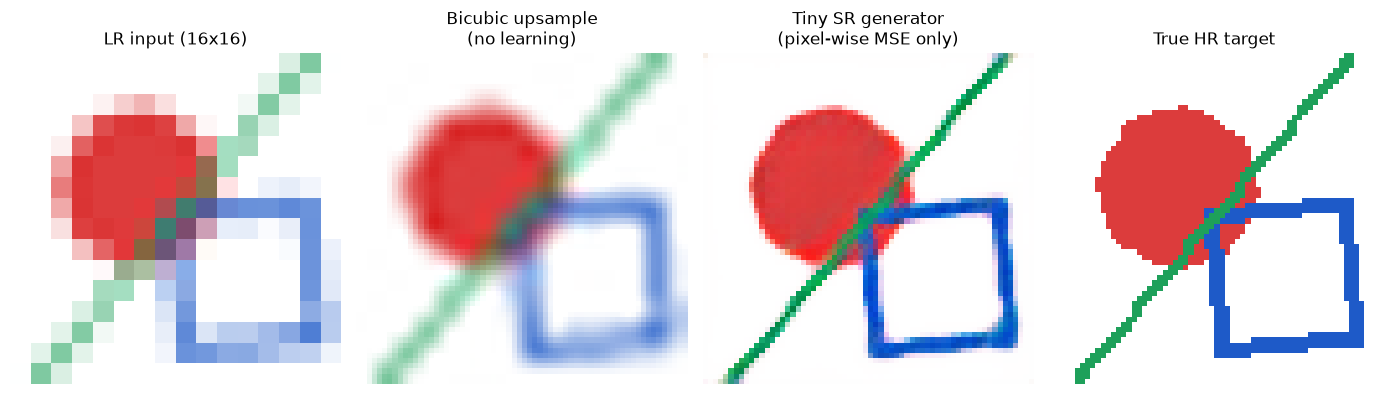

MSE vs. true HR -- bicubic baseline: 0.02186   trained generator: 0.00360
OK -- the trained generator reconstructs the HR target more closely than plain bicubic upsampling.


In [4]:
model.eval()
idx = 0
with torch.no_grad():
    lr_single = lr_batch[idx:idx + 1]
    sr_out = model(lr_single)[0].permute(1, 2, 0).clamp(0, 1).numpy()
    bicubic_out = F.interpolate(
        lr_single, scale_factor=SCALE, mode="bicubic", align_corners=False
    )[0].permute(1, 2, 0).clamp(0, 1).numpy()

lr_display = lr_batch[idx].permute(1, 2, 0).numpy()
hr_display = hr_batch[idx].permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(lr_display); axes[0].set_title(f"LR input ({lr_display.shape[0]}x{lr_display.shape[0]})")
axes[1].imshow(bicubic_out); axes[1].set_title("Bicubic upsample\n(no learning)")
axes[2].imshow(sr_out); axes[2].set_title("Tiny SR generator\n(pixel-wise MSE only)")
axes[3].imshow(hr_display); axes[3].set_title("True HR target")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

mse_bicubic = float(np.mean((bicubic_out - hr_display) ** 2))
mse_generator = float(np.mean((sr_out - hr_display) ** 2))
print(f"MSE vs. true HR -- bicubic baseline: {mse_bicubic:.5f}   trained generator: {mse_generator:.5f}")
assert mse_generator < mse_bicubic, "the trained generator should beat the untrained bicubic baseline"
print("OK -- the trained generator reconstructs the HR target more closely than plain bicubic upsampling.")

## 5. Frame-by-frame application to video (conceptual)

The personal project's final step applies this same per-frame super-resolution model across every
frame of a degraded low-resolution video, then reassembles the upscaled frames into a high-resolution
output video. That loop is simple once the frame-level model exists:

```python
# Illustrative only -- not executed here (no real video file in this offline demo)
import cv2

def upscale_video(input_path, output_path, model, scale):
    cap = cv2.VideoCapture(input_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) * scale)
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) * scale)
    writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        sr_frame = run_sr_model_on_single_frame(model, frame)  # same model as above
        writer.write(sr_frame)

    cap.release()
    writer.release()
```

As Chapter 05 notes, this frame-by-frame approach has no mechanism to enforce **temporal
consistency** across frames -- each frame is upscaled independently, so the model can hallucinate
slightly different fine detail from one frame to the next even in a static region of the scene,
which can show up as subtle flicker in the final video. That's the honest limitation, and the
natural "what would you improve" answer for this project (see `99-Interview-QA.md`).